In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [2]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Exploring games data

In [3]:
clean_games_fp = Path(config['games_folder'] + config['games_clean_fp'])

games_df = pd.read_json(clean_games_fp, orient='records')
games_df['updated_at'] = pd.to_datetime(games_df['updated_at'], errors='coerce')
games_df['first_release_date'] = pd.to_datetime(games_df['first_release_date'], errors='coerce')

games_df.head()

,id,name,total_rating,total_rating_count,updated_at,first_release_date,summary,slug,game_type,height,width,url
0,2592,DEFCON,81.083236,33,2026-05-14 16:35:59,2006-09-29,You play the role of a military commander hidd...,defcon,0,900,675,https://images.igdb.com/igdb/image/upload/t_th...
1,9477,Soldiers: Heroes of World War II,80.123336,23,2026-05-14 16:35:10,2004-06-30,"The player can take control of American, Briti...",soldiersheroesofworldwarii,0,1067,800,https://images.igdb.com/igdb/image/upload/t_th...
2,4840,S.T.A.L.K.E.R.: Clear Sky,77.269801,233,2026-05-14 16:33:29,2008-08-22,Year 2011. Five years passed since the Second ...,sdottadotlkdoterdotclearsky,0,800,600,https://images.igdb.com/igdb/image/upload/t_th...
3,388469,Rocket Cars,-1.000000,-1,2026-05-14 16:29:34,2026-03-31,Rocket-powered cars meet competitive soccer in...,rocketcars1,0,800,600,https://images.igdb.com/igdb/image/upload/t_th...
4,5126,Rogue Trooper,77.476488,36,2026-05-14 16:10:09,2006-04-21,Intense 3rd-person action on the battlefields ...,roguetrooper,0,800,600,https://images.igdb.com/igdb/image/upload/t_th...


In [4]:
games_df.head()

,id,name,total_rating,total_rating_count,updated_at,first_release_date,summary,slug,game_type,height,width,url
0,2592,DEFCON,81.083236,33,2026-05-14 16:35:59,2006-09-29,You play the role of a military commander hidd...,defcon,0,900,675,https://images.igdb.com/igdb/image/upload/t_th...
1,9477,Soldiers: Heroes of World War II,80.123336,23,2026-05-14 16:35:10,2004-06-30,"The player can take control of American, Briti...",soldiersheroesofworldwarii,0,1067,800,https://images.igdb.com/igdb/image/upload/t_th...
2,4840,S.T.A.L.K.E.R.: Clear Sky,77.269801,233,2026-05-14 16:33:29,2008-08-22,Year 2011. Five years passed since the Second ...,sdottadotlkdoterdotclearsky,0,800,600,https://images.igdb.com/igdb/image/upload/t_th...
3,388469,Rocket Cars,-1.000000,-1,2026-05-14 16:29:34,2026-03-31,Rocket-powered cars meet competitive soccer in...,rocketcars1,0,800,600,https://images.igdb.com/igdb/image/upload/t_th...
4,5126,Rogue Trooper,77.476488,36,2026-05-14 16:10:09,2006-04-21,Intense 3rd-person action on the battlefields ...,roguetrooper,0,800,600,https://images.igdb.com/igdb/image/upload/t_th...


In [5]:
#Checking to make sure the id uniquely identifies each row
print("No duplicate IDS") if len(games_df['id'].unique()) == len(games_df) else print("Duplicate IDs found")

No duplicate IDS


In [6]:
#Checking to see if duplicate game names exist
print("No duplicate game names") if len(games_df['name'].unique()) == len(games_df) else print("Duplicate game names found")

Duplicate game names found


In [7]:
#Get all rows with duplicate game names
duplicate_names_df = games_df[games_df.duplicated(subset=['name'], keep=False)].sort_values('name')
duplicate_names_df.head(6)

,id,name,total_rating,total_rating_count,updated_at,first_release_date,summary,slug,game_type,height,width,url
1388,92273,10-Pin Bowling,-1.000000,-1,2026-05-13 00:17:40,1999-08-01,Congratulations! You now own your very own bow...,10pinbowling,0,1413,1060,https://images.igdb.com/igdb/image/upload/t_th...
13873,153453,10-Pin Bowling,-1.000000,-1,2024-11-14 09:33:09,1984-12-31,It's time to go down your local alley and have...,10pinbowling1,0,968,720,https://images.igdb.com/igdb/image/upload/t_th...
8148,4478,Alien Syndrome,65.208294,23,2026-03-25 20:19:59,1987-01-01,The time bomb is set. It's the only sure way t...,aliensyndrome1,0,800,600,https://images.igdb.com/igdb/image/upload/t_th...
11962,273019,Alien Syndrome,-1.000000,-1,2025-11-22 02:42:08,1988-12-02,No summary available,aliensyndrome2,11,800,600,https://images.igdb.com/igdb/image/upload/t_th...
8751,4377,American Gladiators,32.427584,10,2026-03-20 21:03:42,1991-10-01,American Gladiators for NES is based off of th...,americangladiators,0,800,600,https://images.igdb.com/igdb/image/upload/t_th...
12826,273030,American Gladiators,-1.000000,-1,2025-08-12 18:23:07,1992-12-31,American Gladiators is licensed from the popul...,americangladiators2,11,800,600,https://images.igdb.com/igdb/image/upload/t_th...


In [8]:
#Find columns where duplicates differ (excluding name, rating, updated_at, id)
exclude_cols = {'name', 'rating', 'updated_at', 'id'}
cols_to_check = [col for col in duplicate_names_df.columns if col not in exclude_cols]

i = 0
for game_name in duplicate_names_df['name'].unique():
    game_group = duplicate_names_df[duplicate_names_df['name'] == game_name]
    differing_cols = []
    for col in cols_to_check:
        if len(game_group[col].unique()) > 1:
            differing_cols.append(col)
    if'first_release_date' not in differing_cols:  # Print every 10th game to avoid too much output
        #print(f"{game_name}: {differing_cols}")
        pass
    i+=1

There are many duplicates but they may functionally differ so we'll keep them for now

## Conflicts in game modes columns

There are several game mode columns that seem to imply multiplayer functionality (such as Co-operative or Massively Multiplayer Online), but we should check if they actually do inherently imply multiplayer compatibility. If not, we should make sure we understand what the column is referring to.

In [9]:
#coop_without_multiplayer = games_df.groupby(['game_modes_Co-operative', 'game_modes_Multiplayer'])[['name', 'first_release_date']].agg(lambda x: x.sample(1))
#coop_without_multiplayer

For co-op, it seems like an error in entry; games with coop should have a 1 in the multiplayer column.

In [10]:
#br_without_multiplayer = games_df.groupby(['game_modes_Battle Royale', 'game_modes_Multiplayer'])[['name', 'first_release_date']].agg(lambda x: x.sample(1))
#br_without_multiplayer

Same for MMO

# Exploring multiplayer modes data

In [11]:
clean_modes_fp = Path(config['multiplayer_modes_folder'] + config['multiplayer_modes_clean_fp'])

modes_df = pd.read_json(clean_modes_fp, orient='records')

print("Contains " + str(len(modes_df)) + " rows")
modes_df.head()

Contains 19659 rows


,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
0,9953,92273,False,False,False,0,2,False,0,0,22,False
1,7,46076,False,False,False,0,30,False,0,0,6,False
2,10207,31256,False,False,False,0,0,False,0,0,82,False
3,8224,41858,False,False,True,2,2,True,6,6,49,False
4,9247,83341,False,False,False,0,0,True,2,6,6,False


In [12]:
modes_df.isna().mean().sort_values(ascending=False)

id                0.0
game              0.0
dropin            0.0
campaigncoop      0.0
offlinecoop       0.0
offlinecoopmax    0.0
offlinemax        0.0
onlinecoop        0.0
onlinecoopmax     0.0
onlinemax         0.0
platform          0.0
splitscreen       0.0
dtype: float64

-1 as a fill value works fine for all of these

In [13]:
def isunique(df, subset):
    return len(df[subset].unique()) == len(df)

print("No duplicate IDS") if isunique(modes_df, 'id') else print("Duplicate IDs found")
print("No duplicate game ids") if isunique(modes_df, 'game') else print("Duplicate game ids found")

No duplicate IDS
Duplicate game ids found


In [14]:
duplicate_game_ids_df = modes_df[modes_df.duplicated(subset=['game'], keep=False)].sort_values('game')
duplicate_game_ids_df = duplicate_game_ids_df.merge(games_df[['id', 'name']], left_on='game', right_on='id', how='left', suffixes=('_mode', '_game'))
duplicate_game_ids_df.head(10)

,id_mode,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen,id_game,name
0,11592,72,False,False,True,2,0,True,2,0,9,True,72,Portal 2
1,11591,72,False,False,True,2,0,True,2,0,12,True,72,Portal 2
2,11593,72,False,False,True,2,0,True,2,0,6,True,72,Portal 2
3,11595,72,False,False,True,2,0,True,2,0,3,True,72,Portal 2
4,11594,72,False,False,True,2,0,True,2,0,14,True,72,Portal 2
5,1631,83,False,True,True,2,0,False,0,0,8,False,83,Baldur's Gate: Dark Alliance
6,17435,83,False,False,False,0,0,False,0,0,6,True,83,Baldur's Gate: Dark Alliance
7,11138,121,True,True,False,0,0,False,0,0,14,False,121,Minecraft: Java Edition
8,11137,121,True,True,False,0,0,False,0,0,6,False,121,Minecraft: Java Edition
9,11139,121,True,True,False,0,0,False,0,0,3,False,121,Minecraft: Java Edition


Duplicate IDS often seems to indicate multi-platform releases

In [15]:
full_df = modes_df.merge(games_df, left_on='game', right_on='id', how='left', suffixes=('', '_game'))
full_df.head()

,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,...,total_rating,total_rating_count,updated_at,first_release_date,summary,slug,game_type,height,width,url
0,9953,92273,False,False,False,0,2,False,0,0,...,-1.000000,-1,2026-05-13 00:17:40,1999-08-01,Congratulations! You now own your very own bow...,10pinbowling,0,1413,1060,https://images.igdb.com/igdb/image/upload/t_th...
1,7,46076,False,False,False,0,30,False,0,0,...,50.000000,0,2026-05-14 13:21:28,2018-08-30,Aggressors is a historical 4X turn based strat...,aggressorsancientrome,0,-1,-1,https://encrypted-tbn0.gstatic.com/images?q=tb...
2,10207,31256,False,False,False,0,0,False,0,0,...,50.000000,0,2026-04-19 16:42:29,2016-09-20,Pixel-Warfare: Pro is a multiplayer first pers...,pixelwarfarepro,0,215,460,https://images.igdb.com/igdb/image/upload/t_th...
3,8224,41858,False,False,True,2,2,True,6,6,...,70.137315,43,2026-05-12 09:02:41,2016-03-29,Resident Evil 6 Remastered brings the original...,residentevil6remastered,9,1680,1259,https://images.igdb.com/igdb/image/upload/t_th...
4,9247,83341,False,False,False,0,0,True,2,6,...,-1.000000,-1,2026-03-31 05:26:37,2019-01-25,Dwarf is a free-to-play multiplayer online par...,dwarf,0,800,600,https://images.igdb.com/igdb/image/upload/t_th...


## Handling conflicting values across columns

In [16]:
columns = ['offlinecoop', 'offlinecoopmax', 'offlinemax']

def cap_at_1(x):
    return 1 if x >= 1 else x

for col in columns[1:]:
    full_df[col] = full_df[col].apply(cap_at_1)

full_df[columns[-1]].value_counts()

offlinemax
0    13653
1     6006
Name: count, dtype: int64

In [17]:
#Sample one row from each unique combination of columns
selected_cols = ['name', 'first_release_date', 'platform'] + [col for col in full_df.columns if 'game_modes' in col]
conflict_scenarios_df = full_df.groupby(columns)[selected_cols].count()#agg(lambda x: x.sample(1))

#conflict_scenarios_df = conflict_scenarios_df.drop(labels = [()])
conflict_scenarios_df

name  first_release_date  platform
offlinecoop offlinecoopmax offlinemax                                     
False       0              0           12369               12369     12369
                           1            3942                3942      3942
True        1              0            1284                1284      1284
                           1            2064                2064      2064

After inspecting some examples of each combination of the `offlinecoop`, `offlinecoopmax`, and `offlinemax` columns; the meanings can be interpreted as follows:

| offlinecoop | offlinecoopmax | offlinemax | Meaning |
| -------- | ------- | -------- | -------- |
| True | -1 | 1 | Misinput; trust data from games endpoint |
| True | 0 | 1 | Used the other column, fill coop max with max |
| True | 1 | -1 | Offline coop but no PVP |
| True | 1 | 0 | Offline coop but no PVP |
| True | 1 | 1 | Offline coop and PVP |
| False | -1 | -1 | No offline play |
| False | -1 | 0 | No offline play |
| False | -1 | 1 | Offline PVP but no coop |
| False | 0 | -1 | No offline play |
| False | 0 | 0 | No offline play |
| False | 0 | 1 | Inconsistent, assume no offline play |
| False | 1 | -1 | Inconsistent; assume no offline play|
| False | 1 | 0 | Inconsistent; assume no offline play|


There are only 5 error cases:

1. offlinecoop = True, offlinecoopmax \< 0, and offlinemax \> 0 

2. offlinecoop = True, offlinecoopmax = 0, and offlinemax \> 0 

3. offlinecoop = False, offlinecoopmax = 0, and offlinemax \> 0 

4. offlinecoop = False, offlinecoopmax \> 0, and offlinemax \< 0 

5. offlinecoop = False, offlinecoopmax \> 0, and offlinemax = 0 


## Handling Outliers

### Offline multiplayer

In [18]:
offlinemax_column = modes_df['offlinemax'].sort_values(ascending = False)
outliers = offlinemax_column.iloc[:20]

In [19]:
max_games = modes_df.loc[outliers.index]
max_games

,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
12405,33197,336303,True,False,False,0,100,False,0,0,82,False
1375,11658,138335,True,False,True,100,100,True,100,100,55,False
3962,11957,130747,True,False,True,99,99,False,0,0,6,True
3961,11958,130747,True,False,True,99,99,False,0,0,3,True
10962,24662,242408,True,True,True,99,99,True,99,99,3,False
10353,23440,242408,True,True,True,99,99,True,99,99,6,False
17727,37110,297097,True,True,True,12,64,True,12,64,6,False
10142,22917,184413,False,False,False,0,63,True,63,63,6,False
10623,24014,132365,False,False,False,0,50,False,0,50,39,False
10622,24013,132365,False,False,False,0,50,False,0,50,34,False


In [20]:
max_games.merge(games_df, how = 'left', left_on = 'game', right_on = 'id')[['name', 'platform', 'offlinemax']]

,name,platform,offlinemax
0,Redactionary,82,100
1,ScarFall: The Royale Combat,55,100
2,Progress Bar Simulator,6,99
3,Progress Bar Simulator,3,99
4,Counter-Strike 2,3,99
5,Counter-Strike 2,6,99
6,Comando Rio,6,64
7,OpenHV,6,63
8,Balls Royale,39,50
9,Balls Royale,34,50


In [21]:
offlinemax_column.value_counts()

offlinemax
0      13653
2       3209
4       1631
1        570
8        248
6         79
3         73
10        53
16        37
5         36
12        18
32        10
20         8
50         5
29         5
7          5
99         4
14         4
24         3
100        2
30         2
64         1
63         1
28         1
9          1
Name: count, dtype: int64

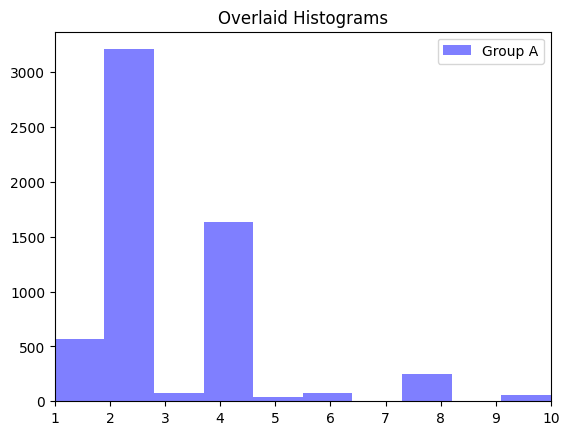

In [22]:
offlinemax_column = offlinemax_column[(1 <= offlinemax_column) & (offlinemax_column <= 10)]

plt.hist(offlinemax_column, alpha=0.5, label='Group A', color='blue')

plt.legend(loc='upper right')
plt.title('Overlaid Histograms')
plt.xlim(1,10)
plt.show()

None of these games actually support over 100 players; we need to drop these outliers.

### Online multiplayer

In [23]:
onlinemax_column = modes_df['onlinemax'].sort_values(ascending = False)
outliers = onlinemax_column.iloc[:20]

In [24]:
max_games = modes_df.loc[outliers.index]
max_games

,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
11773,33323,337715,False,False,True,5,5,True,5,5000,6,False
9025,20827,218762,False,False,False,0,0,True,5000,5000,6,False
9700,22035,231860,False,False,False,0,0,False,0,5000,82,False
9701,22036,231860,False,False,False,0,0,False,0,5000,6,False
16897,33902,342779,True,False,False,0,0,False,0,5000,82,False
19061,40345,396231,False,False,False,0,0,True,5000,5000,82,False
10030,22691,190890,False,False,False,0,0,False,0,5000,6,False
6924,16950,182119,False,False,False,0,0,False,0,4000,34,False
6923,16949,182119,False,False,False,0,0,False,0,4000,39,False
5001,13738,215,False,False,False,0,0,False,0,3500,-1,False


In [25]:
max_games.merge(games_df, how = 'left', left_on = 'game', right_on = 'id')['name']

0                               TakeDogs
1                           Vs Chat Pack
2                   Nitro: Stream Racing
3                   Nitro: Stream Racing
4                               Metacube
5                             Zero-G MMO
6                     Legendarium Online
7                         Ultimate Golf!
8                         Ultimate Golf!
9     Warhammer Online: Age of Reckoning
10                       Ragnarok Online
11                             Castaways
12                        The Bingo Room
13                           KKuTuDotNet
14                                RigorZ
15                               MegaMod
16                            Other Life
17                             RuneScape
18                             titanRose
19                       Skate or Don't!
Name: name, dtype: str

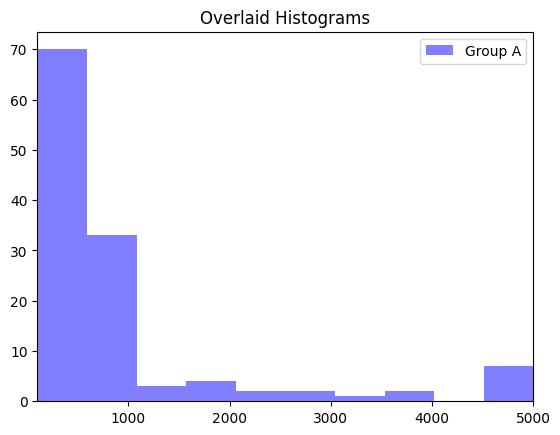

In [26]:
onlinemax_column = onlinemax_column[(100 < onlinemax_column) & (onlinemax_column < 10000)]

plt.hist(onlinemax_column, alpha=0.5, label='Group A', color='blue')

plt.legend(loc='upper right')
plt.title('Overlaid Histograms')
plt.xlim(100, 5000)
plt.show()

In [27]:
modes_df.columns

Index(['id', 'game', 'dropin', 'campaigncoop', 'offlinecoop', 'offlinecoopmax',
       'offlinemax', 'onlinecoop', 'onlinecoopmax', 'onlinemax', 'platform',
       'splitscreen'],
      dtype='str')

After some testing, 5000 seems to be the sweet spot where obviously incorrect data is dropped, leaving only games with truly very high player counts (basically just MMOs)

## Data in Multiplayer Modes that isn't in Games

In [28]:
excluded_ids_mask = ~modes_df['game'].isin(games_df['id'])

excluded_games = modes_df.loc[excluded_ids_mask, 'game'].unique()

excluded_games
len(excluded_games)

0

There's 38 games that, according to the Games endpoint, aren't supposed to have multiplayer anyway. We can't feasibly get the names for these games, so we can drop them from the data